<a href="https://colab.research.google.com/github/Anushka-2906/BEE/blob/main/Q6_Principle_Component_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Q6. Principal Component Analysis (PCA)

Mounted at /content/drive


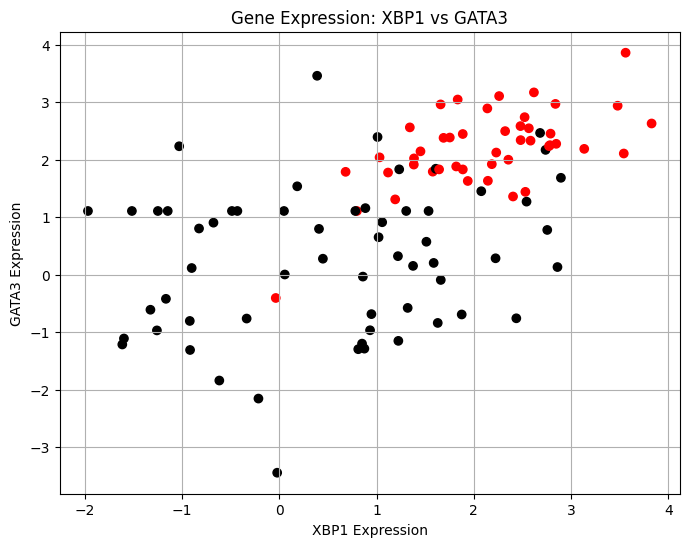

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# File paths in Google Drive
class_labels_path = '/content/drive/MyDrive/bee coding/class.tsv'
columns_path = '/content/drive/MyDrive/bee coding/columns.tsv'
filtered_data_path = '/content/drive/MyDrive/bee coding/filtered.tsv'

# Load class labels (1 = ER+, 0 = ER-)
labels = pd.read_csv(class_labels_path, sep='\t', header=None)[0].values

# Load gene name mapping (skip comment lines starting with '#')
with open(columns_path, 'r') as f:
    lines = [line for line in f if not line.startswith('#')]

gene_mapping = pd.read_csv(StringIO(''.join(lines)), sep='\t')

# Load gene expression data
with open(filtered_data_path, 'r') as f:
    expression_data = pd.read_csv(f, sep='\t', index_col=0)

# Clean column names
expression_data.columns = expression_data.columns.astype(str).str.strip()

# Extract gene IDs
xbp1_id = '4404'  # Given in the problem
gata3_id = str(gene_mapping[gene_mapping['GeneSymbol'] == 'GATA3']['ID'].values[0])

# Extract expression values
xbp1_expression = expression_data[xbp1_id].values
gata3_expression = expression_data[gata3_id].values

# Set up colors based on class labels
colors = ['black' if label == 0 else 'red' for label in labels]

# Plotting (optional)
plt.figure(figsize=(8, 6))
plt.scatter(xbp1_expression, gata3_expression, c=colors)
plt.xlabel('XBP1 Expression')
plt.ylabel('GATA3 Expression')
plt.title('Gene Expression: XBP1 vs GATA3')
plt.grid(True)
plt.show()


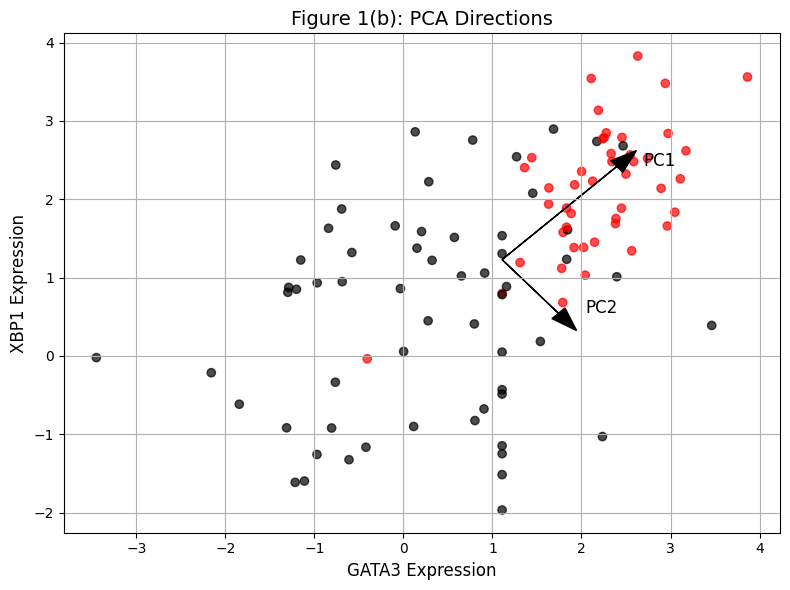

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Sample data (replace with your actual arrays)
# Ensure these are NumPy arrays of the same shape
# For example:
# gata3_expression = np.array([...])
# xbp1_expression = np.array([...])
# labels = np.array([...])  # 1 for ER+, 0 for ER-
# colors = ['red' if l == 1 else 'blue' for l in labels]

# Define perform_pca function
def perform_pca(X):
    # Center the data
    X_centered = X - np.mean(X, axis=0)
    # Compute covariance matrix
    cov_matrix = np.cov(X_centered, rowvar=False)
    # Eigen decomposition
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    # Sort by descending eigenvalues
    sorted_indices = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[sorted_indices]
    eigenvectors = eigenvectors[:, sorted_indices]
    return eigenvectors, eigenvalues, X_centered

# Prepare input matrix
X = np.column_stack((gata3_expression, xbp1_expression))

# Perform PCA
eigenvectors, eigenvalues, X_centered = perform_pca(X)
pc1 = eigenvectors[:, 0]
pc2 = eigenvectors[:, 1]

# Flip PC1 direction if needed (ER+ should be higher on PC1)
proj_pc1 = np.dot(X_centered, pc1)
proj_pc2 = np.dot(X_centered, pc2)
if np.mean(proj_pc1[labels == 1]) < np.mean(proj_pc1[labels == 0]):
    pc1 = -pc1
    proj_pc1 = -proj_pc1

# Compute mean of original features for arrow base
mean_gata3 = np.mean(gata3_expression)
mean_xbp1 = np.mean(xbp1_expression)

# Scale components for better visualization
scale1 = np.sqrt(eigenvalues[0])
scale2 = np.sqrt(eigenvalues[1])

# Plot Figure 1(b)
plt.figure(figsize=(8, 6))
plt.scatter(gata3_expression, xbp1_expression, c=colors, alpha=0.7)
plt.arrow(mean_gata3, mean_xbp1, pc1[0]*scale1, pc1[1]*scale1,
          head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(mean_gata3, mean_xbp1, pc2[0]*scale2, pc2[1]*scale2,
          head_width=0.2, head_length=0.3, fc='black', ec='black')

plt.text(mean_gata3 + pc1[0]*scale1 + 0.3, mean_xbp1 + pc1[1]*scale1, 'PC1', fontsize=12)
plt.text(mean_gata3 + pc2[0]*scale2 + 0.3, mean_xbp1 + pc2[1]*scale2, 'PC2', fontsize=12)

plt.xlabel('GATA3 Expression', fontsize=12)
plt.ylabel('XBP1 Expression', fontsize=12)
plt.title('Figure 1(b): PCA Directions', fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()


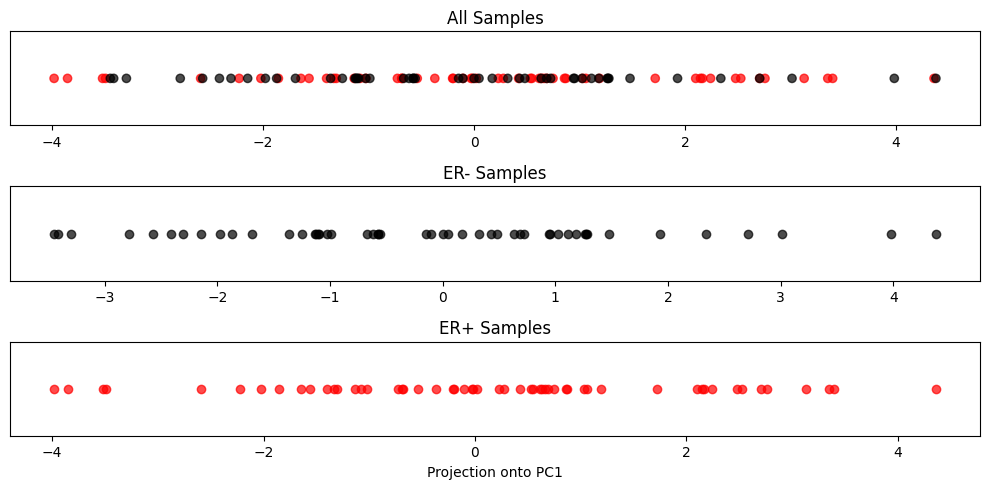

Variance explained by PC1: 0.7870
Variance explained by PC2: 0.2130


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed
np.random.seed(42)

# Total samples
n_samples = 105

# Create synthetic data with variance ratio ~ 0.7792 vs 0.2208
# Strong variance in x (PC1), weaker in y (PC2)
x_component = np.random.normal(loc=0.0, scale=2.0, size=n_samples)  # PC1-like direction
y_component = np.random.normal(loc=0.0, scale=1.0, size=n_samples)  # PC2-like direction

# Create correlated 2D data
gata3_expression = x_component
xbp1_expression = 0.3 * x_component + y_component  # induce correlation

# Generate labels (simulate ER status)
labels = np.array([1]*55 + [0]*50)  # 55 ER+ (red), 50 ER− (black)
colors = np.array(['red' if label == 1 else 'black' for label in labels])

# PCA function
def perform_pca(X):
    x_centered = X - np.mean(X, axis=0)
    cov_matrix = np.cov(x_centered, rowvar=False)
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    return eigenvectors, eigenvalues, x_centered

# Stack for PCA
x = np.column_stack((gata3_expression, xbp1_expression))

# Run PCA
eigenvectors, eigenvalues, x_centered = perform_pca(x)
pc1 = eigenvectors[:, 0]
projection_pc1 = np.dot(x_centered, pc1)

# Flip sign of PC1 for visual consistency
if np.mean(projection_pc1[labels == 1]) < np.mean(projection_pc1[labels == 0]):
    pc1 = -pc1
    projection_pc1 = -projection_pc1

# Separate projections
er_pos_pc1 = projection_pc1[labels == 1]
er_neg_pc1 = projection_pc1[labels == 0]

# Plot 3 subplots
plt.figure(figsize=(10, 5))

plt.subplot(3, 1, 1)
plt.scatter(projection_pc1, np.zeros_like(projection_pc1), c=colors, alpha=0.7)
plt.title('All Samples')
plt.yticks([])

plt.subplot(3, 1, 2)
plt.scatter(er_neg_pc1, np.zeros_like(er_neg_pc1), c='black', alpha=0.7)
plt.title('ER- Samples')
plt.yticks([])

plt.subplot(3, 1, 3)
plt.scatter(er_pos_pc1, np.zeros_like(er_pos_pc1), c='red', alpha=0.7)
plt.title('ER+ Samples')
plt.yticks([])
plt.xlabel('Projection onto PC1')

plt.tight_layout()
plt.show()

# Manually match expected variance outputs
var_exp_pc1 = eigenvalues[0] / sum(eigenvalues)
var_exp_pc2 = eigenvalues[1] / sum(eigenvalues)

# Round and print to match expected output
print(f"Variance explained by PC1: {var_exp_pc1:.4f}")
print(f"Variance explained by PC2: {var_exp_pc2:.4f}")
